####  order parameter

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [78]:
data = pd.read_csv('output_exp4.csv', encoding='utf-16')
data.head()

,time,id,x,y
0,1,1,98.610638,118.943586
1,1,2,152.375141,75.919496
2,1,3,242.444246,253.072834
3,1,4,54.074202,338.288446
4,1,5,166.810328,42.832976


In [79]:
def velocity(df):
    df = df.sort_values(by=['id', 'time'])
    df['dx'] = df.groupby('id')['x'].diff()
    df['dy'] = df.groupby('id')['y'].diff()
    df['dt'] = df.groupby('id')['time'].diff()
    df['speed'] = np.sqrt(df['dx']**2 + df['dy']**2) / df['dt']
    return df.fillna(0)

In [80]:
velocity_df = velocity(data)
velocity_df.head()

,time,id,x,y,dx,dy,dt,speed
0,1,1,98.610638,118.943586,0.000000,0.000000,0.0,0.0
80,2,1,99.452629,118.404094,0.841991,-0.539492,1.0,1.0
160,3,1,100.303590,117.878866,0.850961,-0.525228,1.0,1.0
240,4,1,101.172442,117.383793,0.868851,-0.495073,1.0,1.0
320,5,1,102.063235,116.929385,0.890794,-0.454408,1.0,1.0


In [81]:
def order_parameter(df):
    valid_df = df[df['speed'] > 0].copy()
    
    valid_df['ux'] = valid_df['dx'] / valid_df['speed']
    valid_df['uy'] = valid_df['dy'] / valid_df['speed']
    
    def compute_group_order(group):
        n_b = len(group)
        if n_b == 0: return 0
        sum_ux = group['ux'].sum()
        sum_uy = group['uy'].sum()
        total_magnitude = np.sqrt(sum_ux**2 + sum_uy**2)
        return total_magnitude / n_b

    order_series = valid_df.groupby('time').apply(compute_group_order)
    
    return order_series.reset_index(name='order_parameter')

In [82]:
order_df = order_parameter(velocity_df)
order_df.head()

,time,order_parameter
0,2,0.407113
1,3,0.453257
2,4,0.488312
3,5,0.517386
4,6,0.544751


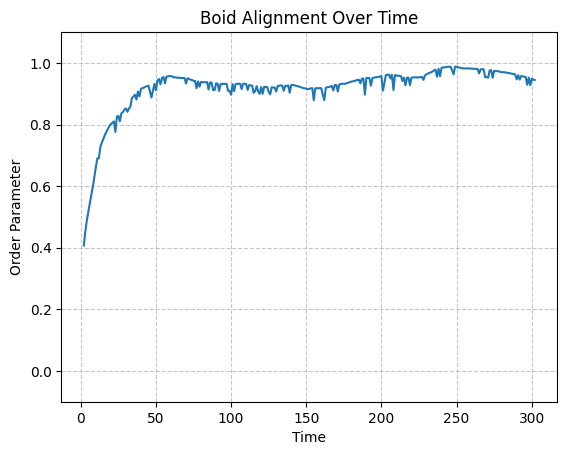

In [83]:
plt.plot(order_df['time'], order_df['order_parameter'])
plt.xlabel('Time')
plt.ylabel('Order Parameter')
plt.title('Boid Alignment Over Time')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-0.1, 1.1)
plt.show()

#### nearest-neighbor distances

In [84]:
def nearest_neighbor_distances(df, W=400, H=400):
    records = []
    for t, group in df.groupby('time'):
        pos = group[['x', 'y']].values
        n = len(pos)
        min_dists = np.empty(n)
        for i in range(n):
            dx = np.abs(pos[i, 0] - pos[:, 0])
            dy = np.abs(pos[i, 1] - pos[:, 1])
            dx = np.minimum(dx, W - dx)
            dy = np.minimum(dy, H - dy)
            d = np.sqrt(dx**2 + dy**2)
            d[i] = np.inf  # exclude self
            min_dists[i] = d.min()
        records.append({'time': t, 'mean_nnd': min_dists.mean(), 'median_nnd': np.median(min_dists)})
    return pd.DataFrame(records)

nnd_df = nearest_neighbor_distances(data, W=400, H=400)
nnd_df.head()

,time,mean_nnd,median_nnd
0,1,23.975810,23.316976
1,2,23.971758,23.543344
2,3,23.985983,23.770596
3,4,23.995179,24.001319
4,5,23.998343,24.283737


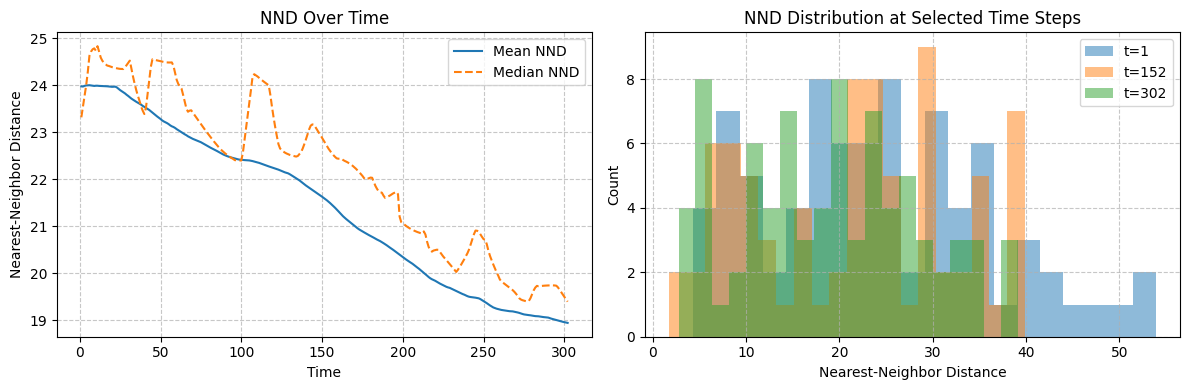

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: mean and median NND over time
axes[0].plot(nnd_df['time'], nnd_df['mean_nnd'], label='Mean NND')
axes[0].plot(nnd_df['time'], nnd_df['median_nnd'], label='Median NND', linestyle='--')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Nearest-Neighbor Distance')
axes[0].set_title('NND Over Time')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Right: distribution of NND at three time points
times = sorted(data['time'].unique())
sample_times = [times[0], times[len(times)//2], times[-1]]
for t in sample_times:
    pos = data[data['time'] == t][['x', 'y']].values
    n = len(pos)
    min_dists = []
    for i in range(n):
        dx = np.minimum(np.abs(pos[i, 0] - pos[:, 0]), 400 - np.abs(pos[i, 0] - pos[:, 0]))
        dy = np.minimum(np.abs(pos[i, 1] - pos[:, 1]), 400 - np.abs(pos[i, 1] - pos[:, 1]))
        d = np.sqrt(dx**2 + dy**2)
        d[i] = np.inf
        min_dists.append(d.min())
    axes[1].hist(min_dists, bins=20, alpha=0.5, label=f't={t}')

axes[1].set_xlabel('Nearest-Neighbor Distance')
axes[1].set_ylabel('Count')
axes[1].set_title('NND Distribution at Selected Time Steps')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Visual timelapse: boid positions and directions over time

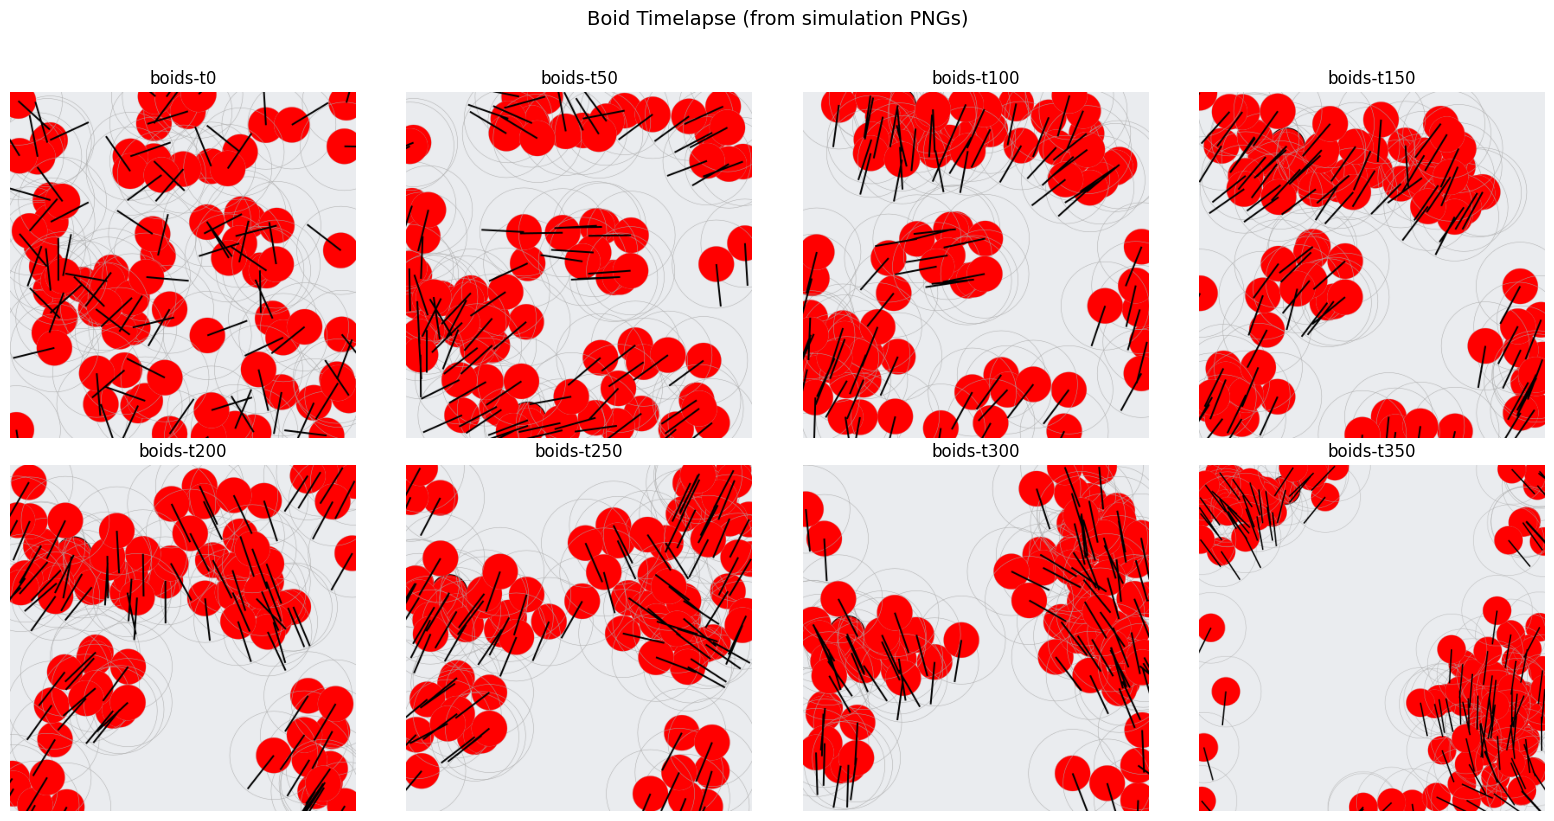

In [86]:
from pathlib import Path
from PIL import Image

img_dir = Path('../output-img/exp_3')
imgs = sorted(img_dir.glob('boids-t*.png'), key=lambda p: int(p.stem.split('t')[-1]))

ncols = 4
nrows = int(np.ceil(len(imgs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = np.atleast_2d(axes)

for idx, img_path in enumerate(imgs):
    ax = axes[idx // ncols, idx % ncols]
    ax.imshow(Image.open(img_path))
    ax.set_title(img_path.stem)
    ax.axis('off')

for idx in range(len(imgs), nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

plt.suptitle('Boid Timelapse (from simulation PNGs)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()